In [1]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import math


In [2]:
# Read input csv file 
df = pd.read_csv('../Data/Sentinel2/Mean_MSAVI_TimeSeries_2020_2025_RDNew.csv')
# Print the first few rows of the DataFrame to verify it loaded correctly
print(df.head(20))

          Date     MSAVI
0   2020-01-18  0.267863
1   2020-02-07  0.270006
2   2020-02-17  0.294328
3   2020-03-21  0.276543
4   2020-03-23  0.288777
5   2020-03-26  0.257632
6   2020-03-28  0.261409
7   2020-03-31  0.272802
8   2020-04-05  0.272257
9   2020-04-07  0.271603
10  2020-04-10  0.263896
11  2020-04-15  0.264620
12  2020-04-17  0.278763
13  2020-04-20  0.279644
14  2020-04-22  0.295179
15  2020-04-27  0.291195
16  2020-04-30  0.288033
17  2020-05-05  0.287980
18  2020-05-07  0.304787
19  2020-05-10  0.287168


In [3]:
# remove NaN values from the MSAVI column
df = df.dropna(subset=['MSAVI'])
# smooth the MSAVI time series using a rolling mean with a window size of 5
df['MSAVI_smoothed'] = df['MSAVI'].rolling(window=5).mean()
# Derive LAI from the smoothed MSAVI using the formula: lai = 12.484 * MSAVI_smoothed - 1.753
df['LAI'] = 12.484 * df['MSAVI_smoothed'] - 1.753
print(df)

           Date     MSAVI  MSAVI_smoothed       LAI
0    2020-01-18  0.267863             NaN       NaN
1    2020-02-07  0.270006             NaN       NaN
2    2020-02-17  0.294328             NaN       NaN
3    2020-03-21  0.276543             NaN       NaN
4    2020-03-23  0.288777        0.279503  1.736320
..          ...       ...             ...       ...
214  2025-10-26  0.364273        0.373909  2.914876
215  2025-11-12  0.330476        0.363222  2.781464
216  2025-11-17  0.356097        0.359193  2.731160
217  2025-12-25  0.325809        0.351436  2.634322
218  2025-12-30  0.304811        0.336293  2.445284

[219 rows x 4 columns]


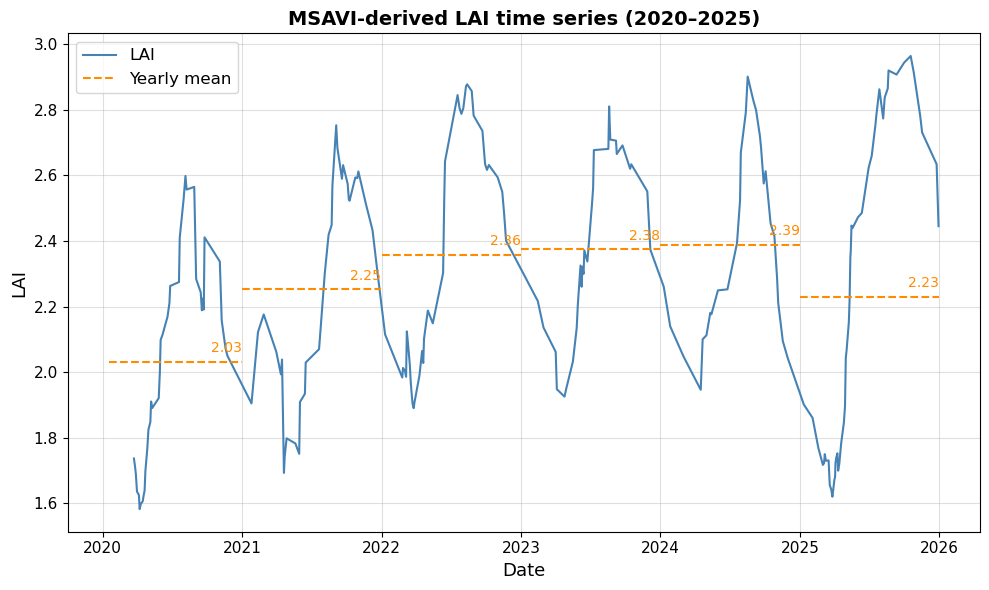

In [4]:
import matplotlib.dates as mdates

df['Date'] = pd.to_datetime(df['Date'])

# Calculate yearly averages
yearly_avg = df.groupby(df['Date'].dt.year)['LAI'].mean()

fig, ax = plt.subplots(figsize=(10, 6))

# Plot continuous LAI line
ax.plot(df['Date'], df['LAI'],
        color='steelblue', linewidth=1.5, label='LAI')

# Plot yearly average as horizontal dashed lines and add text labels
for year, avg in yearly_avg.items():
    year_start = pd.Timestamp(f'{year}-01-01')
    year_end   = pd.Timestamp(f'{year}-12-31')
    # Clip to actual data range
    year_start = max(year_start, df['Date'].min())
    year_end   = min(year_end,   df['Date'].max())

    ax.hlines(avg, year_start, year_end,
              colors='darkorange', linewidth=1.5,
              linestyle='--', label='Yearly mean' if year == yearly_avg.index[0] else '')

    # Add text label at the end of each line
    ax.text(year_end, avg + 0.02, f'{avg:.2f}',
            color='darkorange', fontsize=10, va='bottom', ha='right')

# X-axis: years only
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.set_title('MSAVI-derived LAI time series (2020–2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('LAI', fontsize=13)
ax.tick_params(axis='both', labelsize=11)
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=12)
ax.grid(alpha=0.4)

plt.tight_layout()
plt.show()

In [5]:
# For the year 2025, export the monthly average LAI values to a new CSV file
df_2025 = df[df['Date'].dt.year == 2025]
monthly_avg_2025 = df_2025.groupby(df_2025['Date'].dt.month)['LAI'].mean().reset_index()
monthly_avg_2025.columns = ['Month', 'Average_LAI']
monthly_avg_2025.to_csv('../Data/Sentinel2/Monthly_Avg_LAI_2025.csv', index=False)
print(monthly_avg_2025)

    Month  Average_LAI
0       1     1.901072
1       2     1.814807
2       3     1.695553
3       4     1.750757
4       5     2.260861
5       6     2.527382
6       7     2.765724
7       8     2.849220
8       9     2.907809
9      10     2.941250
10     11     2.756312
11     12     2.539803


In [7]:
# calculate average LAI for whole year 2025
avg_lai_2025 = df_2025['LAI'].mean()
print(f'Average LAI for the whole year 2025: {avg_lai_2025:.2f}')

Average LAI for the whole year 2025: 2.23


In [23]:
# Read seasonal dataset, remove NaN values, and derive LAI
seasonal_df = pd.read_csv('../Data/Sentinel2/MSAVI_TimeSeries_seasonal_2020_2025.csv')
seasonal_df = seasonal_df.dropna(subset=['MSAVI'])
seasonal_df['LAI'] = 12.484 * seasonal_df['MSAVI'] - 1.753
# shows the amount of data entries
print(seasonal_df)

           Date     MSAVI  Season       LAI
0    2019-12-04  0.284005  Winter  1.792515
1    2019-12-12  0.267306  Winter  1.584053
2    2019-12-27  0.302869  Winter  2.028012
3    2020-01-18  0.268173  Winter  1.594868
4    2020-02-07  0.270393  Winter  1.622583
..          ...       ...     ...       ...
221  2025-10-01  0.364690  Autumn  2.799786
222  2025-10-18  0.381854  Autumn  3.014067
223  2025-10-26  0.364892  Autumn  2.802308
224  2025-11-12  0.331808  Autumn  2.389297
225  2025-11-17  0.356543  Autumn  2.698077

[226 rows x 4 columns]


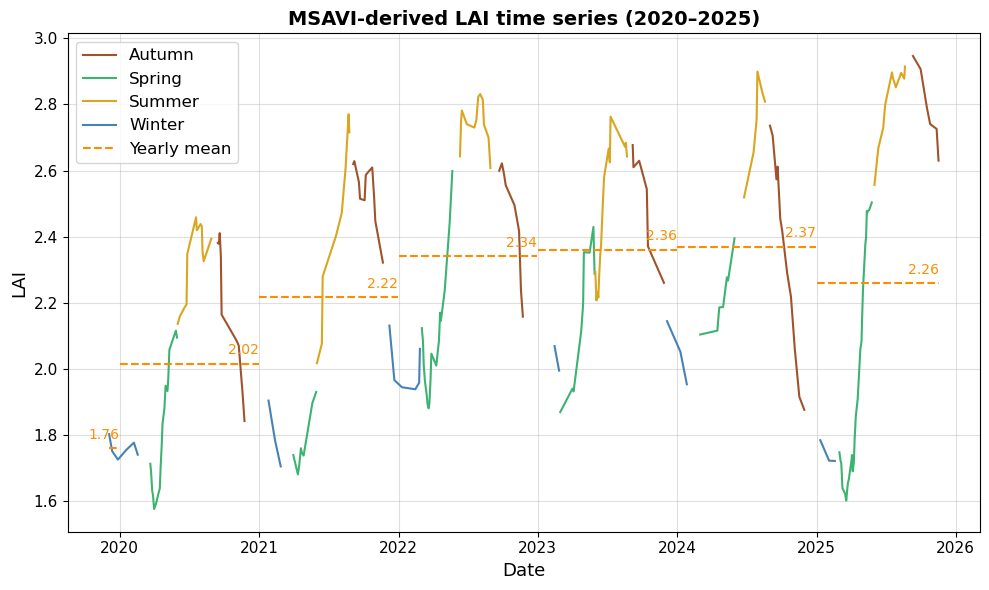

In [19]:
# ----- Load data -----
seasonal_df['Date'] = pd.to_datetime(seasonal_df['Date'])
seasonal_df = seasonal_df.sort_values('Date').reset_index(drop=True)

# ----- Fix winter year grouping: December belongs to the next year's winter -----
seasonal_df['Year'] = seasonal_df['Date'].dt.year
seasonal_df['SeasonYear'] = seasonal_df.apply(
    lambda row: row['Year'] + 1 if (row['Season'] == 'Winter' and row['Date'].month == 12)
    else row['Year'], axis=1
)

# ----- Smooth LAI with 5-point rolling window (across all data, by date order) -----
seasonal_df = seasonal_df.sort_values('Date').reset_index(drop=True)
seasonal_df['LAI_smooth'] = seasonal_df['LAI'].rolling(window=5, center=True, min_periods=1).mean()

# ----- Yearly averages (on smoothed values, by calendar year) -----
yearly_avg = seasonal_df.groupby('Year')['LAI_smooth'].mean()

# ----- Season colours -----
season_colors = {
    "Winter": "steelblue",
    "Spring": "mediumseagreen",
    "Summer": "goldenrod",
    "Autumn": "sienna"
}

# ----- Plot -----
fig, ax = plt.subplots(figsize=(10, 6))

# Plot smoothed LAI — split by Season AND SeasonYear so lines never bridge gaps
legend_seasons = set()
for (season, season_year), group in seasonal_df.groupby(['Season', 'SeasonYear'], sort=True):
    group = group.sort_values('Date')
    label = season if season not in legend_seasons else ''
    legend_seasons.add(season)

    ax.plot(group['Date'], group['LAI_smooth'],
            color=season_colors[season],
            linewidth=1.5, label=label)

# Yearly mean dashed lines + labels
for year, avg in yearly_avg.items():
    year_start = pd.Timestamp(f'{year}-01-01')
    year_end   = pd.Timestamp(f'{year}-12-31')
    year_start = max(year_start, seasonal_df['Date'].min())
    year_end   = min(year_end,   seasonal_df['Date'].max())

    ax.hlines(avg, year_start, year_end,
              colors='darkorange', linewidth=1.5,
              linestyle='--',
              label='Yearly mean' if year == yearly_avg.index[0] else '')

    ax.text(year_end, avg + 0.02, f'{avg:.2f}',
            color='darkorange', fontsize=10, va='bottom', ha='right')

# ----- Axes and labels -----
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.set_title('MSAVI-derived LAI time series (2020–2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('LAI', fontsize=13)
ax.tick_params(axis='both', labelsize=11)
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=12)
ax.grid(alpha=0.4)

plt.tight_layout()
plt.show()